In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

data = pd.read_csv(r'D:\常用软件\vscode\daolun\bike.csv')

data = data.drop(columns=['id'])

data_shanghai = data[data['city'] == 1].drop(columns=['city'])

data_shanghai['hour'] = data_shanghai['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)

labels = data_shanghai.pop('y').values.reshape(-1, 1)

features = data_shanghai.values

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f'均方根误差 (RMSE): {rmse}')

均方根误差 (RMSE): 31.568478635113294


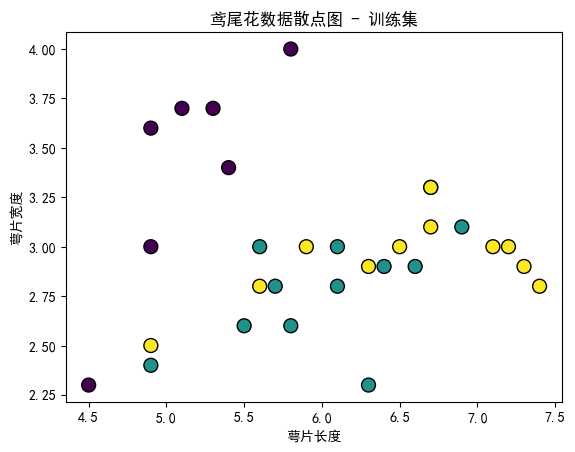

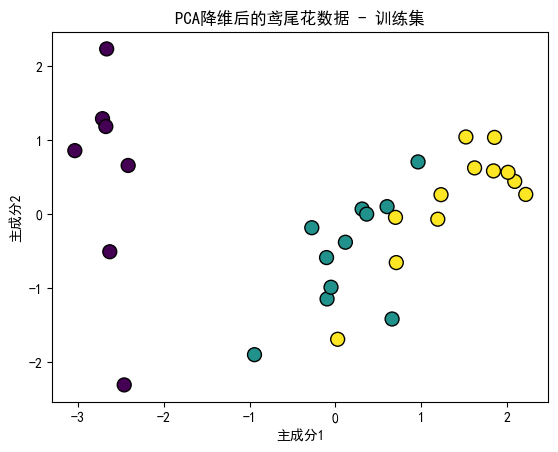

分类准确率: 95.0%


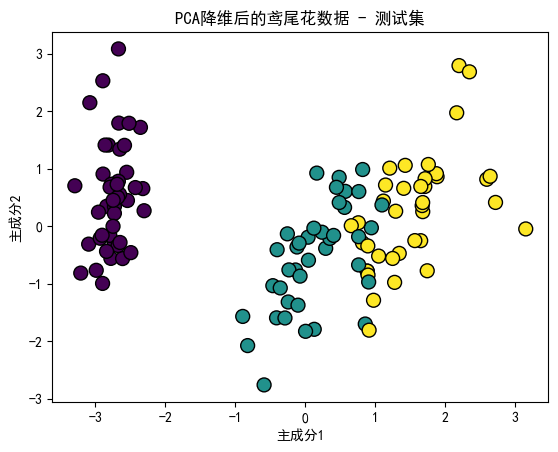

In [11]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('萼片长度')
plt.ylabel('萼片宽度')
plt.title('鸢尾花数据散点图 - 训练集')
plt.show()

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.title('PCA降维后的鸢尾花数据 - 训练集')
plt.show()

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'分类准确率: {accuracy * 100}%')

plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.title('PCA降维后的鸢尾花数据 - 测试集')
plt.show()